# Daten importieren

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
df = pd.read_csv('gdrive/My Drive/Predicting Air Quality in Cities around the World/processed_data.csv')

# Machine Learning Models

## Lineare Regression mit SKlearn

### Spalten auswählen und Daten splitten

In [ ]:
# Liste aller Städte
cities = df['city'].unique()
n_cities = len(cities)

# Städte zufällig aufteilen (80% train, 20% test, reproduzierbar)
np.random.seed(42)
n_train = int(n_cities * 0.8)
train_cities = np.random.choice(cities, size=n_train, replace=False)
test_cities = np.setdiff1d(cities, train_cities)

In [ ]:
# DataFrames nach Städte-Split aufteilen
train_mask = df['city'].isin(train_cities)
test_mask = df['city'].isin(test_cities)

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()


In [ ]:
# Spalten entfernen, Zielvariable festlegen
drop_cols = ['year', 'city', 'country_code', 'country']
X_train = train_df.drop(columns=drop_cols + ['pm25'])
y_train = train_df['pm25']

X_test = test_df.drop(columns=drop_cols + ['pm25'])
y_test = test_df['pm25']


In [ ]:
# Monatsdummies erzeugen
X_train = pd.get_dummies(X_train, columns=['month'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['month'], drop_first=True, dtype=int)

# Fehlende Spalten angleichen (falls nötig)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### Lineare Regression mit Cross Validation trainieren

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Cross-Validation auf Trainingsset ---
# Modell
lr = LinearRegression()

# 5-fold Cross-Validation (robuste Mittelwerte, Shuffle für mehr Robustheit)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
cv_r2_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='r2')
print("Cross-Validation R²:", cv_r2_scores)
print(f"CV R² Mittelwert: {cv_r2_scores.mean():.3f} ± {cv_r2_scores.std():.3f}")

# MAE
cv_mae_scores = -cross_val_score(lr, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE:", cv_mae_scores)
print(f"CV MAE Mittelwert: {cv_mae_scores.mean():.2f} ± {cv_mae_scores.std():.2f}")

# MSE & RMSE
cv_mse_scores = -cross_val_score(lr, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(cv_mse_scores)
print("Cross-Validation MSE:", cv_mse_scores)
print(f"CV MSE Mittelwert: {cv_mse_scores.mean():.2f} ± {cv_mse_scores.std():.2f}")
print("CV RMSE Mittelwert: %.2f ± %.2f" % (cv_rmse_scores.mean(), cv_rmse_scores.std()))

print("\n--- Finale Bewertung auf Trainings- und Testset ---")

# --- 2. Modell auf ganzem Trainingsset trainieren ---
lr.fit(X_train, y_train)

# Vorhersagen
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# --- 3. Metriken berechnen ---
def evaluate(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.3f}")

print("Training-Set:")
evaluate(y_train, y_train_pred, "  ")
print("Test-Set:")
evaluate(y_test, y_test_pred, "  ")


Cross-Validation R²: [0.59441101 0.56729527 0.5256028  0.49064057 0.72275705]
CV R² Mittelwert: 0.580 ± 0.080
Cross-Validation MAE: [4.15245811 4.32508607 5.07054877 4.73973133 4.27374952]
CV MAE Mittelwert: 4.51 ± 0.34
Cross-Validation MSE: [33.5043648  40.1487573  65.69866801 64.16094816 38.40779851]
CV MSE Mittelwert: 48.38 ± 13.69
CV RMSE Mittelwert: 6.89 ± 0.97

--- Finale Bewertung auf Trainings- und Testset ---
Training-Set:
  MSE: 44.33, RMSE: 6.66, MAE: 4.32, R²: 0.618
Test-Set:
  MSE: 394.27, RMSE: 19.86, MAE: 8.80, R²: 0.367


#### Residuenanalyse

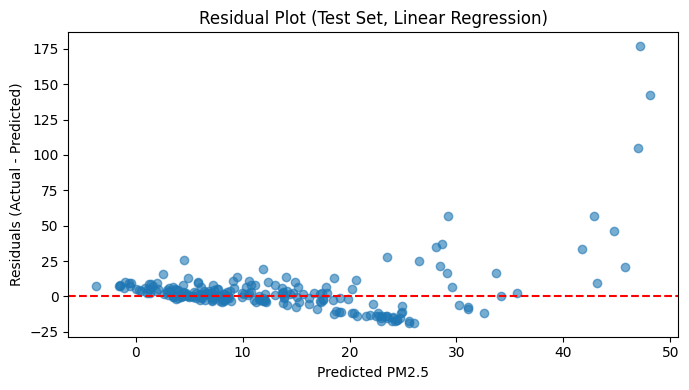

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# --- 1. Residuen berechnen ---
residuals = y_test - y_test_pred

# --- 2. Residuenplot ---
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Linear Regression)")
plt.tight_layout()
plt.show()

* Fehler bei niedrigen/mittleren Vorhersagen überwiegend klein, bei hohen Vorhersagen starke Ausreißer (insbesondere nach oben).
* Residuen zeigen keine perfekte Symmetrie, bei hohen vorhergesagten PM2.  
* 5-Werten häufen sich positive Fehler (Modell unterschätzt hohe Werte).
* Hinweise auf Heteroskedastizität: Die Streuung der Residuen wächst mit steigendem Vorhersagewert.
* Einzelne sehr große Ausreißer sind sichtbar.

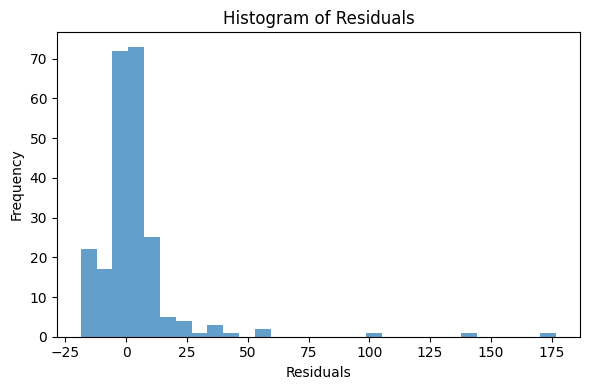

In [ ]:
# --- 3. Histogramm der Residuen ---
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

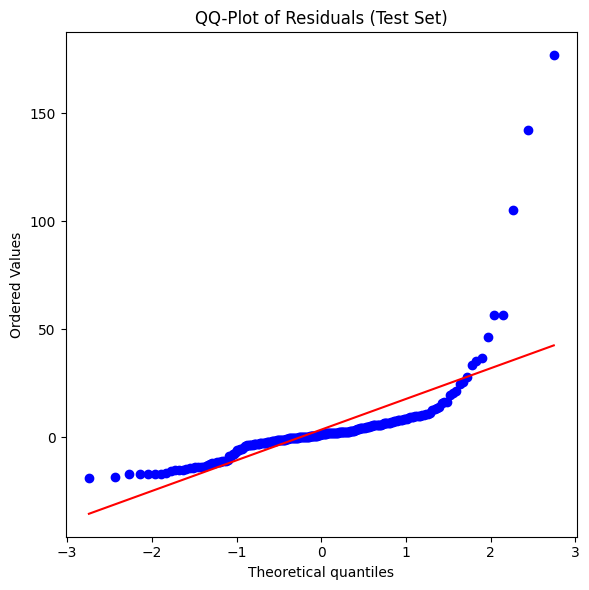

In [ ]:
# --- 4. QQ-Plot (optional, prüft auf Normalverteilung der Fehler) ---
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals (Test Set)")
plt.tight_layout()
plt.show()

* Deutliche Abweichung von der Geraden am rechten Rand: Residuen sind nicht normalverteilt (Ausreißer/Schiefe).
* Die meisten Werte liegen für kleine Quantile nahe an der Linie, aber starke Ausreißer nach oben (positive Fehler).
* Hinweis auf Modellprobleme bei Extremwerten und mangelnde Symmetrie in den Fehlern.

### Untersuchung, ob log **oder** sqrt() Transformation der Zielvariable das Ergebnis der linReg verbessert


Log-Transformation - CV R²: 0.649 ± 0.052
Log-Transformation - Test R²: 0.3265005374237713
Log-Transformation Test-Set:      MSE: 419.279
Log-Transformation Test-Set:      MAE: 8.249


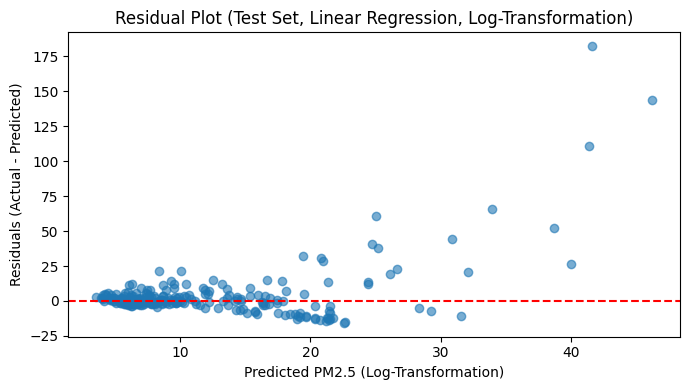

In [ ]:
# Log Transformation
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- Log-Transformation ---
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
lr_log = LinearRegression()
cv_scores_log = cross_val_score(lr_log, X_train, y_train_log, cv=cv, scoring='r2')
print(f"\nLog-Transformation - CV R²: {cv_scores_log.mean():.3f} ± {cv_scores_log.std():.3f}")

lr_log.fit(X_train, y_train_log)
y_test_pred_log = lr_log.predict(X_test)
y_test_pred_inv_log = np.expm1(y_test_pred_log)

print("Log-Transformation - Test R²:", r2_score(y_test, y_test_pred_inv_log))
print("Log-Transformation Test-Set:      MSE: %.3f" % mean_squared_error(y_test, y_test_pred_inv_log))
print("Log-Transformation Test-Set:      MAE: %.3f" % mean_absolute_error(y_test, y_test_pred_inv_log))

# --- Residuenplot für Log-Transformation ---
residuals_log = y_test - y_test_pred_inv_log
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred_inv_log, residuals_log, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Log-Transformation)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Linear Regression, Log-Transformation)")
plt.tight_layout()
plt.show()



* Performance mit log-transfomierter Zielvariable ist minimal schlechter


### Ridge, Lasso und ElasticNet mit Skalierung und GridSearch

Gegen Overfitting


Ridge - Bestes Alpha: 100
Ridge - CV R²: 0.583
Ridge Training-Set:  R²: 0.613
Ridge Test-Set:      R²: 0.349
Ridge Test-Set:      MSE: 405.429
Ridge Test-Set:      MAE: 8.504


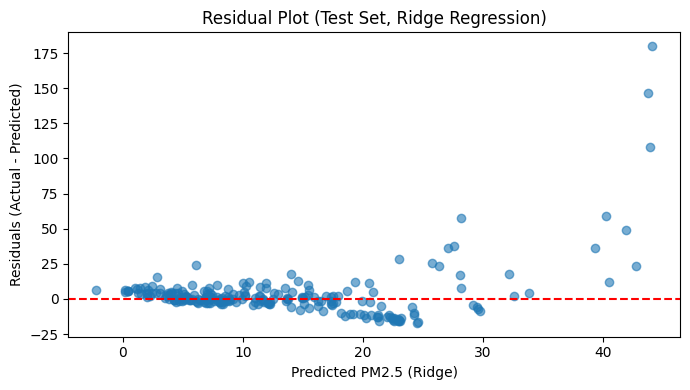

In [ ]:
# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1, 10, 100]}

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

gs_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=cv, scoring='r2')
gs_ridge.fit(X_train, y_train)

print("\nRidge - Bestes Alpha:", gs_ridge.best_params_['ridge__alpha'])
print("Ridge - CV R²: %.3f" % gs_ridge.best_score_)

ridge_best = gs_ridge.best_estimator_
y_train_pred = ridge_best.predict(X_train)
y_test_pred = ridge_best.predict(X_test)
print("Ridge Training-Set:  R²: %.3f" % r2_score(y_train, y_train_pred))
print("Ridge Test-Set:      R²: %.3f" % r2_score(y_test, y_test_pred))
print("Ridge Test-Set:      MSE: %.3f" % mean_squared_error(y_test, y_test_pred))
print("Ridge Test-Set:      MAE: %.3f" % mean_absolute_error(y_test, y_test_pred))


# Residuenplot
import matplotlib.pyplot as plt

residuals_ridge = y_test - ridge_best.predict(X_test)
plt.figure(figsize=(7, 4))
plt.scatter(ridge_best.predict(X_test), residuals_ridge, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Ridge)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Ridge Regression)")
plt.tight_layout()
plt.show()




Lasso - Bestes Alpha: 0.05
Lasso - CV R²: 0.583
Lasso Training-Set:  R²: 0.616
Lasso Test-Set:      R²: 0.352
Lasso Test-Set:      MSE: 403.565
Lasso Test-Set:      MAE: 8.771
Features mit Koeffizient = 0 (aus dem Modell entfernt):
     feature  coefficient
4   avg_temp          0.0
23   month_3          0.0
31  month_11         -0.0


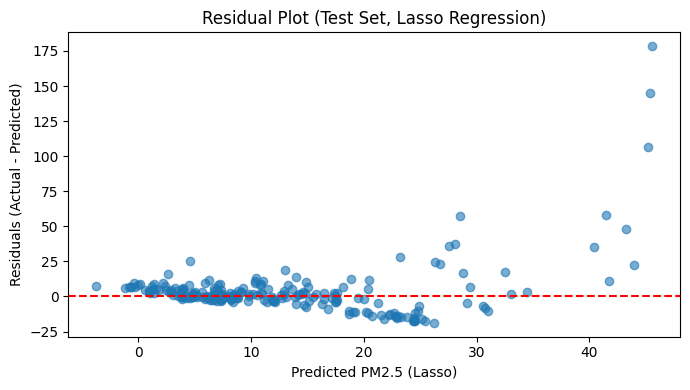

In [ ]:
# Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lasso = {'lasso__alpha': [0.01, 0.05, 0.1, 0.5, 1]}
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42, max_iter=10000))
])

gs_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=cv, scoring='r2')
gs_lasso.fit(X_train, y_train)

print("\nLasso - Bestes Alpha:", gs_lasso.best_params_['lasso__alpha'])
print("Lasso - CV R²: %.3f" % gs_lasso.best_score_)

lasso_best = gs_lasso.best_estimator_
y_train_pred = lasso_best.predict(X_train)
y_test_pred = lasso_best.predict(X_test)
print("Lasso Training-Set:  R²: %.3f" % r2_score(y_train, y_train_pred))
print("Lasso Test-Set:      R²: %.3f" % r2_score(y_test, y_test_pred))
print("Lasso Test-Set:      MSE: %.3f" % mean_squared_error(y_test, y_test_pred))
print("Lasso Test-Set:      MAE: %.3f" % mean_absolute_error(y_test, y_test_pred))

# Prüfen, ob Lasso Features auf 0 gesetzt hat:
coef = lasso_best.named_steps['lasso'].coef_ # Access coef_ from the Lasso model within the pipeline
feature_names = X_train.columns

# DataFrame für Übersicht
lasso_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
})

# Zeige alle Features mit Koeffizient exakt 0
null_features = lasso_coef_df[lasso_coef_df['coefficient'] == 0]
print("Features mit Koeffizient = 0 (aus dem Modell entfernt):")
print(null_features)

# Residuenplot:
residuals_lasso = y_test - lasso_best.predict(X_test)
plt.figure(figsize=(7, 4))
plt.scatter(lasso_best.predict(X_test), residuals_lasso, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Lasso)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Lasso Regression)")
plt.tight_layout()
plt.show()


ElasticNet - Beste Parameter: {'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 0.1}
ElasticNet - CV R²: 0.584
ElasticNet Training-Set:  R²: 0.614
ElasticNet Test-Set:      R²: 0.350
ElasticNet Test-Set:      MSE: 404.944
ElasticNet Test-Set:      MAE: 8.542
ElasticNet Features mit Koeffizient = 0:
     feature  coefficient
31  month_11          0.0


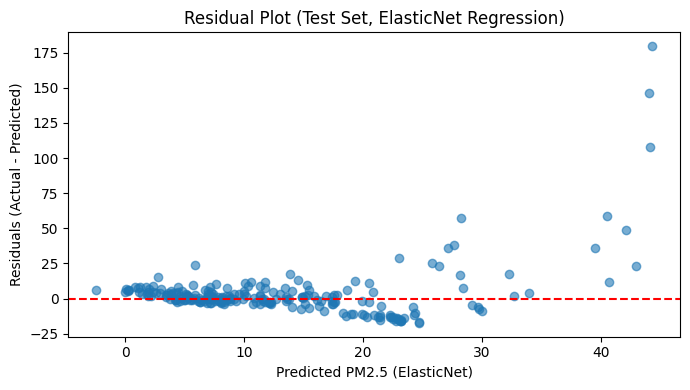

In [ ]:
# ElasticNet Regression (kombiniert Lasso und Ridge)
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_enet = {
    'elasticnet__alpha': [0.01, 0.05, 0.1, 0.5, 1],
    'elasticnet__l1_ratio': [0.1, 0.5, 0.9]
}
enet_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(random_state=42, max_iter=10000))
])

gs_enet = GridSearchCV(enet_pipe, param_grid_enet, cv=cv, scoring='r2')
gs_enet.fit(X_train, y_train)

print("\nElasticNet - Beste Parameter:", gs_enet.best_params_)
print("ElasticNet - CV R²: %.3f" % gs_enet.best_score_)

enet_best = gs_enet.best_estimator_
y_train_pred = enet_best.predict(X_train)
y_test_pred = enet_best.predict(X_test)
print("ElasticNet Training-Set:  R²: %.3f" % r2_score(y_train, y_train_pred))
print("ElasticNet Test-Set:      R²: %.3f" % r2_score(y_test, y_test_pred))
print("ElasticNet Test-Set:      MSE: %.3f" % mean_squared_error(y_test, y_test_pred))
print("ElasticNet Test-Set:      MAE: %.3f" % mean_absolute_error(y_test, y_test_pred))


# Prüfen, ob Features auf 0 gesetzt hat:
coef = enet_best.named_steps['elasticnet'].coef_
feature_names = X_train.columns

enet_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
})

print("ElasticNet Features mit Koeffizient = 0:")
print(enet_coef_df[enet_coef_df['coefficient'] == 0])

# Residuenplot
residuals_enet = y_test - enet_best.predict(X_test)
plt.figure(figsize=(7, 4))
plt.scatter(enet_best.predict(X_test), residuals_enet, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (ElasticNet)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, ElasticNet Regression)")
plt.tight_layout()
plt.show()

Interpretation:  
* Performance aller Modelle ist relativ ähnlich
* Ridge generalisiert unter den regularisierten Modellen am besten
* Residuenplots sehen alle sehr ähnlich aus: Modelle stoßen an das gleiche, datengetriebene Limit (weder Regularisierung noch Feature-Auswahl (Lasso, ElasticNet) können systematische Fehler reduzieren)
* Limitation liegt an den Daten und nicht am Modell

Was ist unser bestes lineares Regressionsmodell?
* R2 ist nahezu identisch.  
    --> Modelle generalisieren ähnlich, keines over- oder underfitted weniger als die andern.  
    --> Regularisierung bringt praktisch keinen Vorteil, da keine massiven Overfitting-Tendenzen und keine stark irrelevanten Features vorliegen
* Unser bestes lineares Modell ist die einfache Lineare Regression

## Decision Trees

### Spalten auswählen und Daten splitten

In [ ]:
# Liste aller Städte
cities = df['city'].unique()
n_cities = len(cities)

# Städte zufällig aufteilen (80% train, 20% test, reproduzierbar)
np.random.seed(42)
n_train = int(n_cities * 0.8)
train_cities = np.random.choice(cities, size=n_train, replace=False)
test_cities = np.setdiff1d(cities, train_cities)

In [ ]:
# DataFrames nach Städte-Split aufteilen
train_mask = df['city'].isin(train_cities)
test_mask = df['city'].isin(test_cities)

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()


In [ ]:
# Spalten entfernen, Zielvariable festlegen
drop_cols = ['year', 'city', 'country_code', 'country']
X_train = train_df.drop(columns=drop_cols + ['pm25'])
y_train = train_df['pm25']

X_test = test_df.drop(columns=drop_cols + ['pm25'])
y_test = test_df['pm25']


In [ ]:
# Monatsdummies erzeugen
X_train = pd.get_dummies(X_train, columns=['month'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['month'], drop_first=True, dtype=int)

# Fehlende Spalten angleichen (falls nötig)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### Decision Tree Standardmodell

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- 1. Modell trainieren ---
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# --- 2. Vorhersagen und Metriken ---
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

print("Decision Tree Regressor (Standardmodell)")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))
print("Test  MSE: %.3f" % mean_squared_error(y_test, y_test_pred))
print("Test  MAE: %.3f" % mean_absolute_error(y_test, y_test_pred))

# --- 3. Cross-Validation (auf Trainingsset) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='r2')
print("CV R2 Scores:", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

Decision Tree Regressor (Standardmodell)
Train R2: 1.000
Test  R2: 0.303
Test  MSE: 434.198
Test  MAE: 9.747
CV R2 Scores: [0.64596406 0.54369446 0.30539555 0.70339161 0.63330991]
CV R2 Mittelwert: 0.566 ± 0.140


Totales Overfitting:  
* Der Baum lernt auswendig und kann nur schlecht auf neue Ergebnisse generalisieren.
* Cross-Validation Scores variieren sehr stark
* Modell ist durch Overfitting nicht generalisierungsfähig

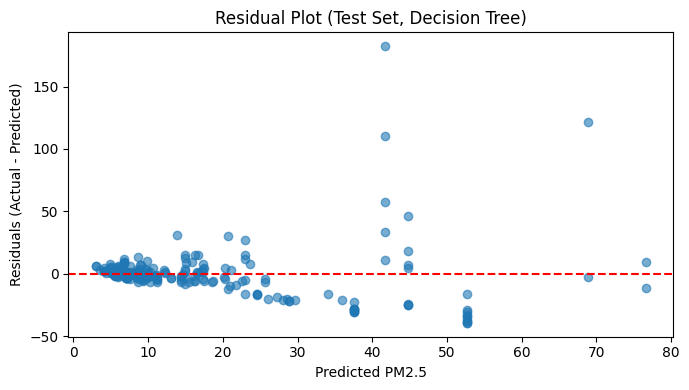

In [ ]:
# --- 4. Fehleranalyse: Residuenplot ---
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Decision Tree)")
plt.tight_layout()
plt.show()

* Sehr viele Fehler liegen nahe Null, aber einige extrem große Ausreißer nach oben.
* Modell trifft viele Werte exakt, unterschätzt aber manche hohe PM2.5-Werte massiv.
* Typisch für Overfitting beim Standardbaum: Im Testset werden Ausreißer nicht erkannt/erklärt.
* Fehlerstruktur ist uneinheitlich und wenig robust – Hinweis, dass das Modell zu komplex und schlecht generalisierbar ist.

### Decision Tree GridSearch Hyperparameter bestimmen

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- 1. Cross-Validation für das Standardmodell ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='r2')
print("CV R2 Scores:", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

# --- 2. Hyperparameter-Tuning mit GridSearchCV ---
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
dt = DecisionTreeRegressor(random_state=42)
gs_dt = GridSearchCV(dt, param_grid, cv=cv, scoring='r2', n_jobs=-1)
gs_dt.fit(X_train, y_train)
print("Beste Parameter:", gs_dt.best_params_)
print("Bestes CV R2 (GridSearch): %.3f" % gs_dt.best_score_)

# --- 3. Bewertung des besten Modells ---
best_dt = gs_dt.best_estimator_
y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\nBestes Modell (Decision Tree)")
print("Train: MSE %.2f, MAE %.2f, R2 %.3f" % (mse_train, mae_train, r2_train))
print("Test:  MSE %.2f, MAE %.2f, R2 %.3f" % (mse_test, mae_test, r2_test))

CV R2 Scores: [0.64596406 0.54369446 0.30539555 0.70339161 0.63330991]
CV R2 Mittelwert: 0.566 ± 0.140
Beste Parameter: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Bestes CV R2 (GridSearch): 0.712

Bestes Modell (Decision Tree)
Train: MSE 12.21, MAE 2.04, R2 0.895
Test:  MSE 333.06, MAE 8.83, R2 0.465


Mit Wahl der Hyperparameter lernt der Baum weniger auswendig und kann neue Werte besser vorhersagen.

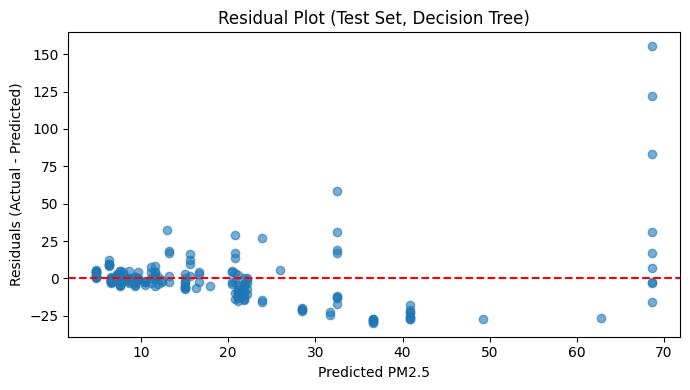

In [ ]:
# --- 4. Fehleranalyse: Residuenplot ---
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Decision Tree)")
plt.tight_layout()
plt.show()

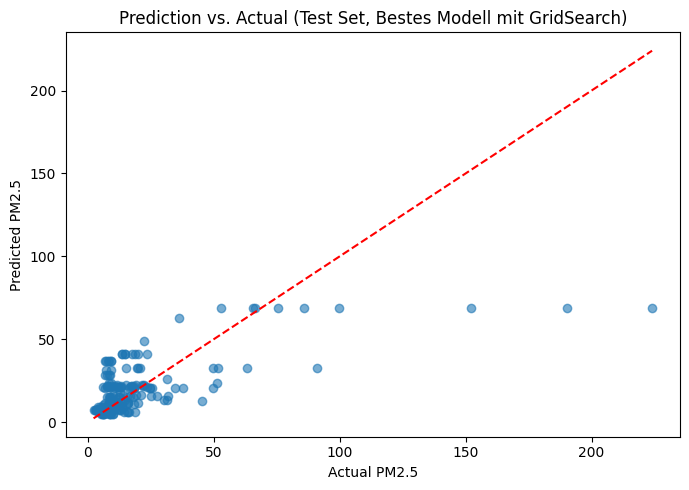

In [ ]:
# Plot zu Vorhersagegenauigkeit
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Prediction vs. Actual (Test Set, Bestes Modell mit GridSearch)")
plt.tight_layout()
plt.show()

### Decision Tree Modell mit transformierter Zielvariable (log und sqrt())

In [ ]:
# Log-Transformation
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Log-Transformation
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt_log = DecisionTreeRegressor(random_state=42)
gs_dt_log = GridSearchCV(dt_log, param_grid, cv=cv, scoring='r2', n_jobs=-1)
gs_dt_log.fit(X_train, y_train_log)

print("Log-Transformation: Beste Parameter:", gs_dt_log.best_params_)
print("Log-Transformation: Bestes CV R2: %.3f" % gs_dt_log.best_score_)

best_dt_log = gs_dt_log.best_estimator_

# Vorhersagen im Log-Raum und Rücktransformation
y_train_pred_log = best_dt_log.predict(X_train)
y_test_pred_log = best_dt_log.predict(X_test)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# Metriken im Originalraum
print("\nDecision Tree (Log-Transformation)")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))

Log-Transformation: Beste Parameter: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Log-Transformation: Bestes CV R2: 0.704

Decision Tree (Log-Transformation)
Train R2: 0.906
Test  R2: 0.416


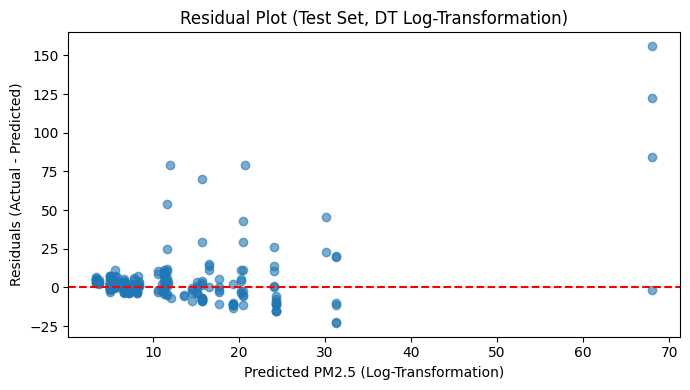

In [ ]:
# Fehleranalyse: Residuenplot
residuals_log = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals_log, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Log-Transformation)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, DT Log-Transformation)")
plt.tight_layout()
plt.show()

In [ ]:
# Sqrt-Transformation
y_train_sqrt = np.sqrt(y_train)
y_test_sqrt = np.sqrt(y_test)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt_sqrt = DecisionTreeRegressor(random_state=42)
gs_dt_sqrt = GridSearchCV(dt_sqrt, param_grid, cv=cv, scoring='r2', n_jobs=-1)
gs_dt_sqrt.fit(X_train, y_train_sqrt)

print("Sqrt-Transformation: Beste Parameter:", gs_dt_sqrt.best_params_)
print("Sqrt-Transformation: Bestes CV R2: %.3f" % gs_dt_sqrt.best_score_)

best_dt_sqrt = gs_dt_sqrt.best_estimator_

# Vorhersagen im Sqrt-Raum und Rücktransformation
y_train_pred_sqrt = best_dt_sqrt.predict(X_train)
y_test_pred_sqrt = best_dt_sqrt.predict(X_test)
y_train_pred = y_train_pred_sqrt ** 2
y_test_pred = y_test_pred_sqrt ** 2

# Metriken im Originalraum
print("\nDecision Tree (Sqrt-Transformation)")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))

Sqrt-Transformation: Beste Parameter: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Sqrt-Transformation: Bestes CV R2: 0.706

Decision Tree (Sqrt-Transformation)
Train R2: 0.910
Test  R2: 0.402


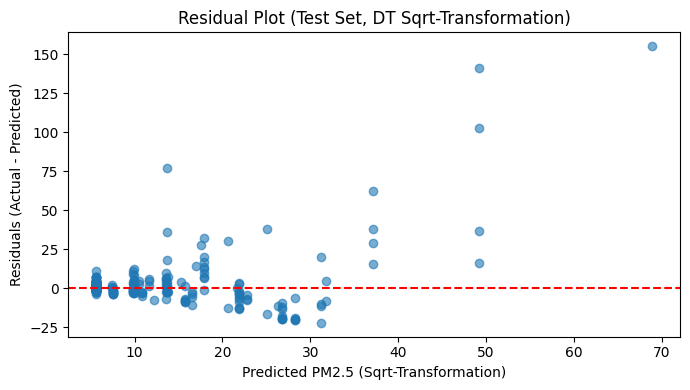

In [ ]:
# Fehleranalyse: Residuenplot
residuals_sqrt = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals_sqrt, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Sqrt-Transformation)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, DT Sqrt-Transformation)")
plt.tight_layout()
plt.show()

* Modellperformance wird durch beide Transformationen klar schlechter
* Entscheidungsbäume brauchen keine Transformation, da diese mit Schiefe gut umgehen können

**Man nutzt keine Transformation bei Treebased Models**

### Decision Tree Feature Importance untersuchen

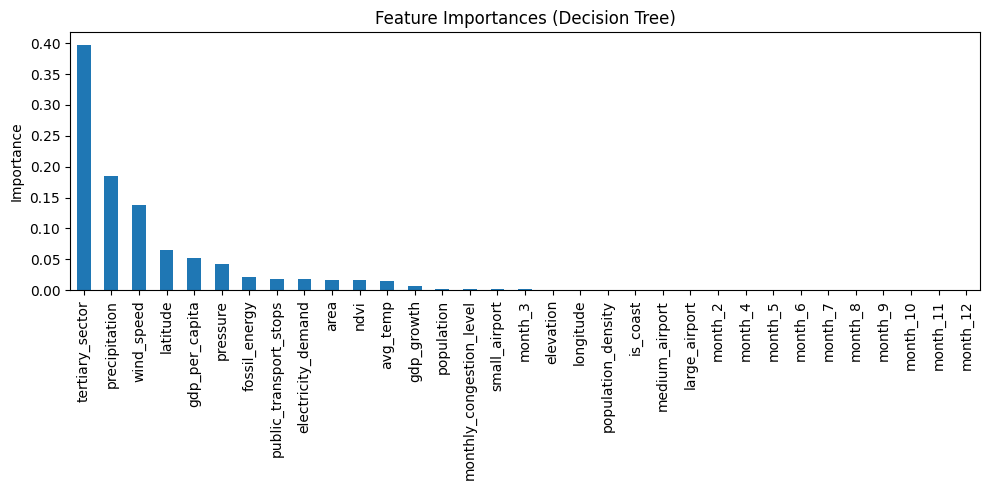

Top 10 wichtigste Features:
tertiary_sector           0.397669
precipitation             0.184074
wind_speed                0.137992
latitude                  0.064732
gdp_per_capita            0.052034
pressure                  0.042522
fossil_energy             0.021888
public_transport_stops    0.018828
electricity_demand        0.017612
area                      0.017165
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wichtig: Das Modell sollte 'best_dt' oder wie von dir benannt sein
# Feature-Namen aus X_train
feature_names = X_train.columns

# Feature Importances abrufen und sortieren
feat_imp = pd.Series(best_dt.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.ylabel('Importance')
plt.title('Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()

# Die Top-10 wichtigsten Features als Tabelle ausgeben
print("Top 10 wichtigste Features:")
print(feat_imp.head(12))


Viele Features haben keinen Einfluss auf die Vorhersage des Modells.  
--> Ein Modell mit weniger Features trainieren (Weniger Rauschen / weniger Overfitting, bessere Vorhersage erwartet)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Nur Features mit Importance > 0.01 auswählen
important_features = feat_imp[feat_imp > 0.01].index.tolist()
print("Verwendete Features:", important_features)

# 2. Trainings- und Testdaten reduzieren
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

# 3. Modell mit besten Parametern neu trainieren
dt_reduced = DecisionTreeRegressor(**best_dt.get_params())
dt_reduced.fit(X_train_reduced, y_train)

# 4. Auswertung
y_train_pred = dt_reduced.predict(X_train_reduced)
y_test_pred = dt_reduced.predict(X_test_reduced)

print("\nKompaktes Modell (nur wichtige Features):")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))
print("Test MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("Test MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

Verwendete Features: ['tertiary_sector', 'precipitation', 'wind_speed', 'latitude', 'gdp_per_capita', 'pressure', 'fossil_energy', 'public_transport_stops', 'electricity_demand', 'area', 'ndvi', 'avg_temp']

Kompaktes Modell (nur wichtige Features):
Train R2: 0.893
Test  R2: 0.469
Test MAE: 8.73
Test MSE: 330.82


* Viele der ursprünglich genutzten Features waren redundant oder haben Rauschen/Unschärfe eingebracht.
* Durch Reduktion auf die wichtigsten Prädiktoren wird das Modell robuster, einfacher und generalisiert besser.
* Feature Selection nach Importance hilft, Overfitting zu reduzieren – das Modell konzentriert sich auf die „echten“ Einflussgrößen.
* Die wichtigsten Merkmale tragen praktisch die gesamte Vorhersagekraft.
* Ein kompakterer Baum ist oft stabiler, schneller und besser interpretierbar.

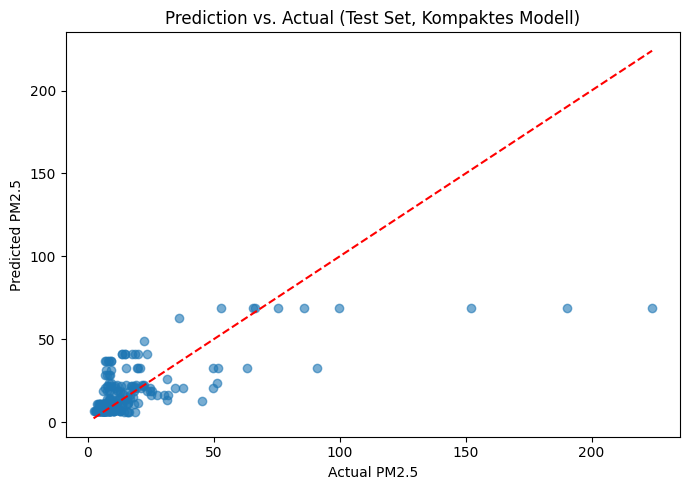

In [ ]:
# Plot zu Vorhersagegenauigkeit
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Prediction vs. Actual (Test Set, Kompaktes Modell)")
plt.tight_layout()
plt.show()


* Die meisten Vorhersagen liegen im Bereich niedriger bis mittlerer PM2.5-Werte nahe an der Idealgeraden (rote Linie).
* Starke Unterschätzung bei hohen tatsächlichen PM2.5-Werten:
Für große Istwerte (weit rechts) bleiben die Vorhersagen deutlich darunter.
* Kaum Vorhersagen im Bereich extremer Werte:
Das Modell "traut" sich keine sehr hohen PM2.5-Werte vorherzusagen, auch wenn sie im Test vorkommen.
* Gute Modellgüte im typischen Wertebereich, Schwächen bei Ausreißern und Extremwerten.
* Das ist typisch für Entscheidungsbäume auf rechtsschiefen Daten mit Ausreißern.

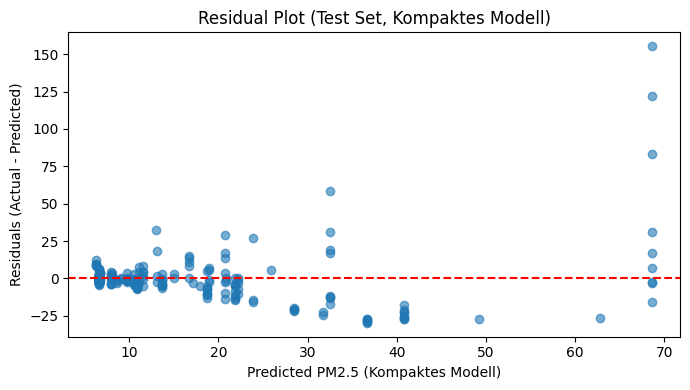

In [ ]:
# Residuenplot
import matplotlib.pyplot as plt

residuals = y_test - y_test_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Kompaktes Modell)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Kompaktes Modell)")
plt.tight_layout()
plt.show()

* Die meisten Residuen liegen im Bereich niedriger und mittlerer Vorhersagen nah an Null.
* Große positive Residuen bei hohen Vorhersagen:
Einige Punkte zeigen erhebliche Unterschätzung hoher PM2.5-Werte (Residuen > 50, teils > 100).
* Fehlerstreuung nimmt mit steigender Vorhersage zu (Trichterform), typisch bei Modellen mit Ausreißern und rechtsschiefen Zielverteilungen.
* Im Hauptbereich arbeitet das Modell präzise, Ausreißer bleiben aber eine Herausforderung.
* Kein klares systematisches Muster außer bei den Extremwerten.

Modell ist insgesamt robust, aber wie bisher alle getesteten Modelle bleibt die Vorhersage extremer PM2.5 Werte schwierig

### Tree Plot

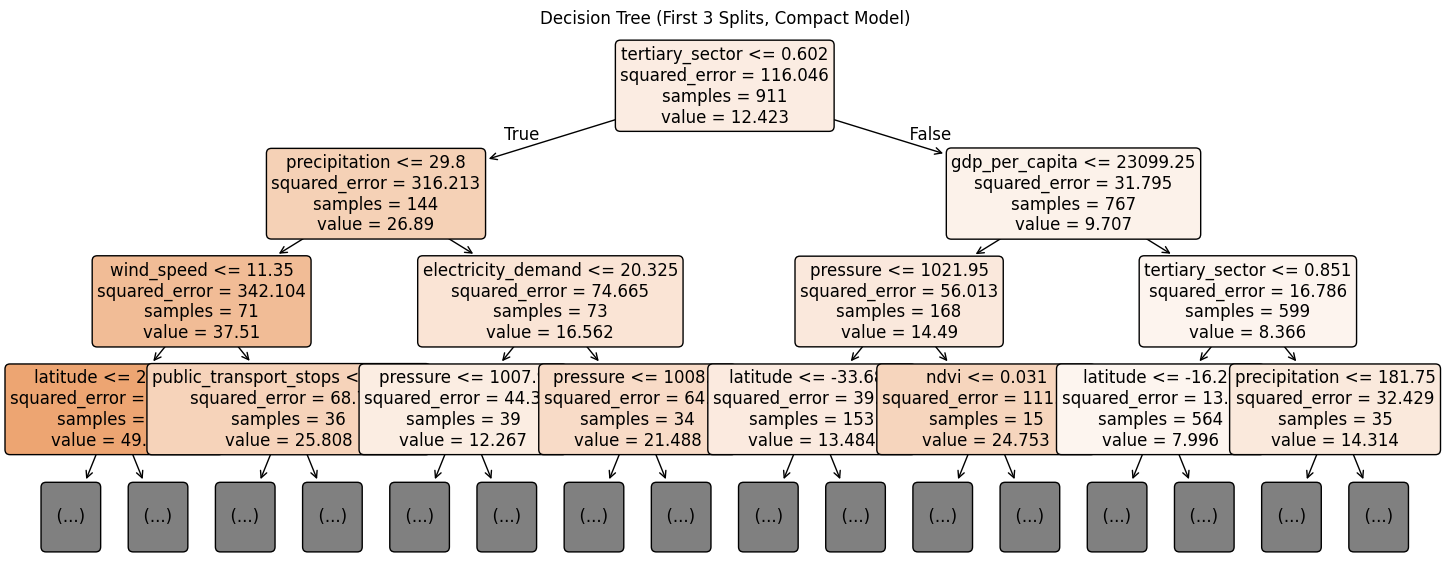

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 7))
plot_tree(
    dt_reduced,
    feature_names=X_train_reduced.columns,
    filled=True,
    rounded=True,
    max_depth=3,      # nur die ersten Splits zeigen!
    fontsize=12
)
plt.title("Decision Tree (First 3 Splits, Compact Model)")
plt.show()


## Random Forest

### Spalten auswählen und Daten splitten

In [ ]:
# Liste aller Städte
cities = df['city'].unique()
n_cities = len(cities)

# Städte zufällig aufteilen (80% train, 20% test, reproduzierbar)
np.random.seed(42)
n_train = int(n_cities * 0.8)
train_cities = np.random.choice(cities, size=n_train, replace=False)
test_cities = np.setdiff1d(cities, train_cities)

In [ ]:
# DataFrames nach Städte-Split aufteilen
train_mask = df['city'].isin(train_cities)
test_mask = df['city'].isin(test_cities)

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()


In [ ]:
# Spalten entfernen, Zielvariable festlegen
drop_cols = ['year',  'city', 'country_code', 'country']
X_train = train_df.drop(columns=drop_cols + ['pm25'])
y_train = train_df['pm25']

X_test = test_df.drop(columns=drop_cols + ['pm25'])
y_test = test_df['pm25']


In [ ]:
# Monatsdummies erzeugen
X_train = pd.get_dummies(X_train, columns=['month'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['month'], drop_first=True, dtype=int)

# Fehlende Spalten angleichen (falls nötig)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### RandomForest Standardmodell

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Modell initialisieren und trainieren
rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)

# 2. Cross-Validation auf dem Trainingsset
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
print("Random Forest CV R2:", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

# 3. Training und Test-Auswertung
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("\nRandom Forest - Training-Set:")
print("R2:  %.3f" % r2_score(y_train, y_train_pred))
print("MAE: %.2f" % mean_absolute_error(y_train, y_train_pred))
print("MSE: %.2f" % mean_squared_error(y_train, y_train_pred))

print("\nRandom Forest - Test-Set:")
print("R2:  %.3f" % r2_score(y_test, y_test_pred))
print("MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

Random Forest CV R2: [0.81996804 0.82867703 0.80655284 0.70165808 0.88938361]
CV R2 Mittelwert: 0.809 ± 0.061

Random Forest - Training-Set:
R2:  0.975
MAE: 0.93
MSE: 2.90

Random Forest - Test-Set:
R2:  0.496
MAE: 7.36
MSE: 313.61


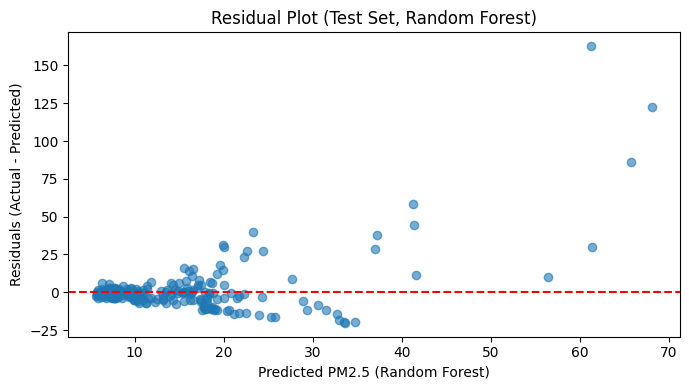

In [ ]:
# 4. Fehleranalyse: Residuenplot
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Random Forest)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Random Forest)")
plt.tight_layout()
plt.show()


### RandomForest mit GridSearch

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Grid für Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, 12, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 20]
}

# 2. Modell und Cross-Validation-Setup
rf = RandomForestRegressor(random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_rf = GridSearchCV(rf, param_grid, cv=cv, scoring='r2', n_jobs=-1, verbose=2)
gs_rf.fit(X_train, y_train)

print("\nBeste Parameter (Random Forest):", gs_rf.best_params_)
print("Bestes CV R2: %.3f" % gs_rf.best_score_)

# 3. Bestes Modell auswerten
best_rf = gs_rf.best_estimator_
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

print("\nRandom Forest (Bestes Modell) - Training-Set:")
print("R2:  %.3f" % r2_score(y_train, y_train_pred))
print("MAE: %.2f" % mean_absolute_error(y_train, y_train_pred))
print("MSE: %.2f" % mean_squared_error(y_train, y_train_pred))

print("\nRandom Forest (Bestes Modell) - Test-Set:")
print("R2:  %.3f" % r2_score(y_test, y_test_pred))
print("MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

Fitting 5 folds for each of 160 candidates, totalling 800 fits

Beste Parameter (Random Forest): {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Bestes CV R2: 0.812

Random Forest (Bestes Modell) - Training-Set:
R2:  0.953
MAE: 1.15
MSE: 5.51

Random Forest (Bestes Modell) - Test-Set:
R2:  0.485
MAE: 7.37
MSE: 320.75


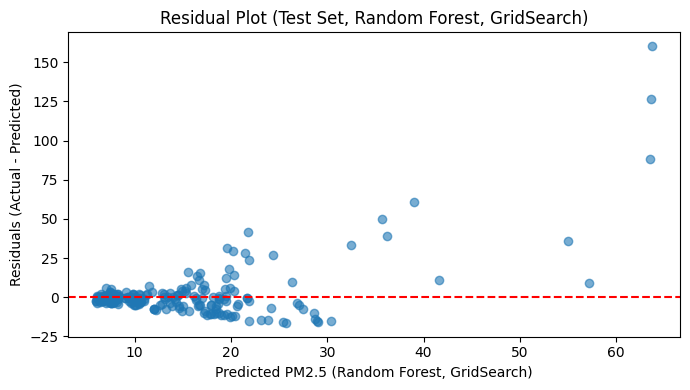

In [ ]:
# 4. Fehleranalyse: Residuenplot
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Random Forest, GridSearch)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Random Forest, GridSearch)")
plt.tight_layout()
plt.show()

### RandomForest Feature Importance untersuchen

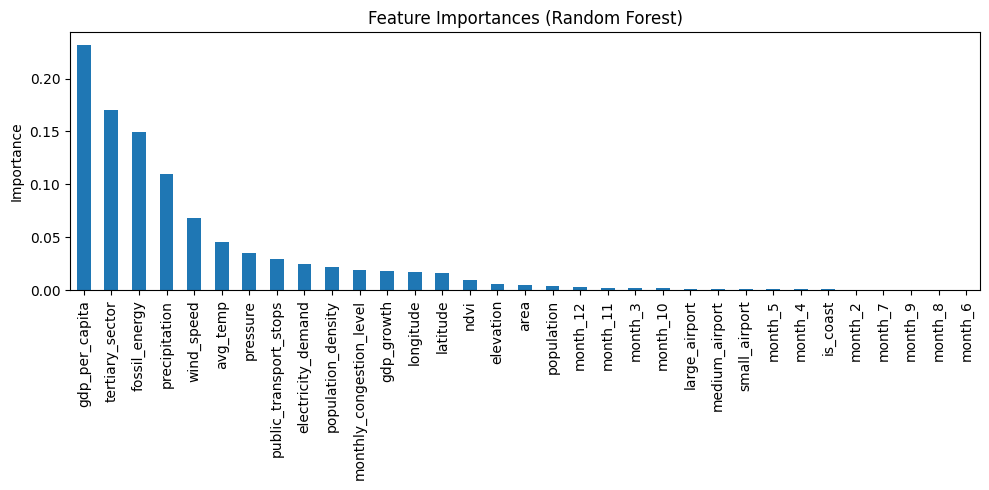

Top 10 wichtigste Features (Random Forest):
gdp_per_capita            0.232081
tertiary_sector           0.170647
fossil_energy             0.149110
precipitation             0.109804
wind_speed                0.068487
avg_temp                  0.045177
pressure                  0.035087
public_transport_stops    0.029845
electricity_demand        0.024376
population_density        0.022213
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importances auslesen (best_rf ist dein optimiertes Modell)
feature_names = X_train.columns  # oder X_train_reduced.columns für das kompakte Modell
feat_imp = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.ylabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

# Die wichtigsten Features (z. B. Top 10) ausgeben
print("Top 10 wichtigste Features (Random Forest):")
print(feat_imp.head(10))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Wichtigste Features bestimmen
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
important_features = feat_imp[feat_imp > 0.01].index.tolist()
print("Verwendete Features:", important_features)

# 2. Trainings- und Testdaten auf diese Features reduzieren
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

# 3. Modell mit den besten (oder Standard-)Parametern trainieren
rf_reduced = RandomForestRegressor(**best_rf.get_params())
rf_reduced.fit(X_train_reduced, y_train)

# 4. Auswertung
y_train_pred = rf_reduced.predict(X_train_reduced)
y_test_pred = rf_reduced.predict(X_test_reduced)

print("\nKompaktes Random Forest Modell (nur wichtige Features):")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))
print("Test MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("Test MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

Verwendete Features: ['latitude', 'longitude', 'avg_temp', 'precipitation', 'wind_speed', 'pressure', 'electricity_demand', 'fossil_energy', 'population_density', 'public_transport_stops', 'monthly_congestion_level', 'gdp_per_capita', 'gdp_growth', 'tertiary_sector']

Kompaktes Random Forest Modell (nur wichtige Features):
Train R2: 0.953
Test  R2: 0.504
Test MAE: 7.26
Test MSE: 308.69


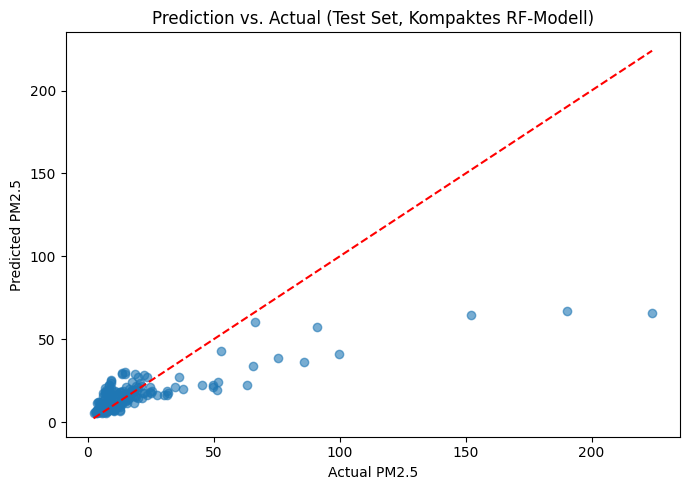

In [ ]:
# Prediction vs. Actual (Scatterplot)
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Prediction vs. Actual (Test Set, Kompaktes RF-Modell)")
plt.tight_layout()
plt.show()


* Die Vorhersagen liegen im typischen PM2.5-Bereich eng an der Idealgeraden.
* Hohe tatsächliche PM2.5-Werte werden wieder systematisch unterschätzt; das Modell gibt kaum extrem hohe Vorhersagen aus.
* Gute Modellgüte im Hauptbereich, Schwächen bei Ausreißern bleiben.

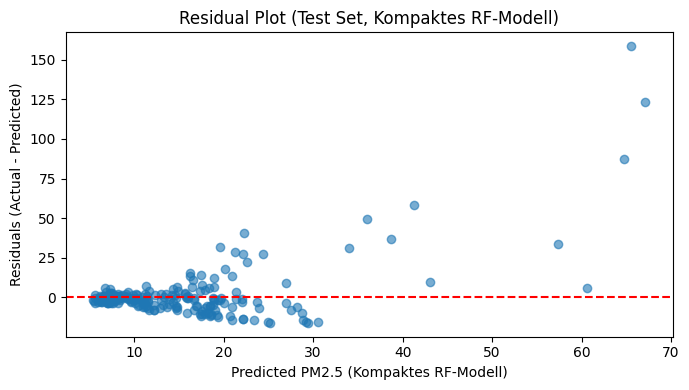

In [ ]:
# Residuenplot
residuals = y_test - y_test_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Kompaktes RF-Modell)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Kompaktes RF-Modell)")
plt.tight_layout()
plt.show()

* Fehler (Residuen) bei niedrigen/mittleren Werten klein und symmetrisch.
* Bei hohen Vorhersagen einige große, positive Residuen – Modell unterschätzt seltene, sehr hohe PM2.5-Werte.
* Insgesamt robust, aber Ausreißer bleiben eine Herausforderung.

**Metrik-Vergleich**.

Standardmodell (ohne Gridsearch):
* Test R²: 0.498 (bestes Einzelmodell bis jetzt!)
* Sehr gute Modellgüte im Training (R²: 0.975), aber deutlicher Leistungsabfall auf Testdaten (leichter Overfitting-Effekt).  

Mit Gridsearch:
* Test R²: 0.488, leicht schlechter als Standardmodell.
* Gridsearch bringt keine echte Verbesserung, da der Test-R² sogar etwas sinkt.  

Kompaktes Modell (Importance > 0.01):
* Test R²: 0.506 (bester Wert von allen!)
* Fehlermaße (MAE, MSE) ebenfalls minimal besser.
* Reduktion auf wenige, wichtige Features verbessert die Generalisierung.
* Das Modell bleibt robust, schlank und interpretiert die wichtigsten Einflussgrößen.

## Gradient Boosting

### Spalten auswählen und Daten splitten

In [ ]:
# Liste aller Städte
cities = df['city'].unique()
n_cities = len(cities)

# Städte zufällig aufteilen (80% train, 20% test, reproduzierbar)
np.random.seed(42)
n_train = int(n_cities * 0.8)
train_cities = np.random.choice(cities, size=n_train, replace=False)
test_cities = np.setdiff1d(cities, train_cities)

In [ ]:
# DataFrames nach Städte-Split aufteilen
train_mask = df['city'].isin(train_cities)
test_mask = df['city'].isin(test_cities)

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()


In [ ]:
# Spalten entfernen, Zielvariable festlegen
drop_cols = ['year',  'city', 'country_code', 'country']
X_train = train_df.drop(columns=drop_cols + ['pm25'])
y_train = train_df['pm25']

X_test = test_df.drop(columns=drop_cols + ['pm25'])
y_test = test_df['pm25']


In [ ]:
# Monatsdummies erzeugen
X_train = pd.get_dummies(X_train, columns=['month'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['month'], drop_first=True, dtype=int)

# Fehlende Spalten angleichen (falls nötig)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### Gradient Boosting Standardmodell

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor  # schneller als klassisches GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Modell initialisieren und trainieren
gb = HistGradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

# 2. Cross-Validation (Trainingsset)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb, X_train, y_train, cv=cv, scoring='r2')
print("Gradient Boosting CV R2:", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

# 3. Training und Test-Auswertung
y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

print("\nGradient Boosting - Training-Set:")
print("R2:  %.3f" % r2_score(y_train, y_train_pred))
print("MAE: %.2f" % mean_absolute_error(y_train, y_train_pred))
print("MSE: %.2f" % mean_squared_error(y_train, y_train_pred))

print("\nGradient Boosting - Test-Set:")
print("R2:  %.3f" % r2_score(y_test, y_test_pred))
print("MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("MSE: %.2f" % mean_squared_error(y_test, y_test_pred))


Gradient Boosting CV R2: [0.83760294 0.82595695 0.79014152 0.77661839 0.87778906]
CV R2 Mittelwert: 0.822 ± 0.036

Gradient Boosting - Training-Set:
R2:  0.969
MAE: 0.94
MSE: 3.56

Gradient Boosting - Test-Set:
R2:  0.498
MAE: 7.41
MSE: 312.58


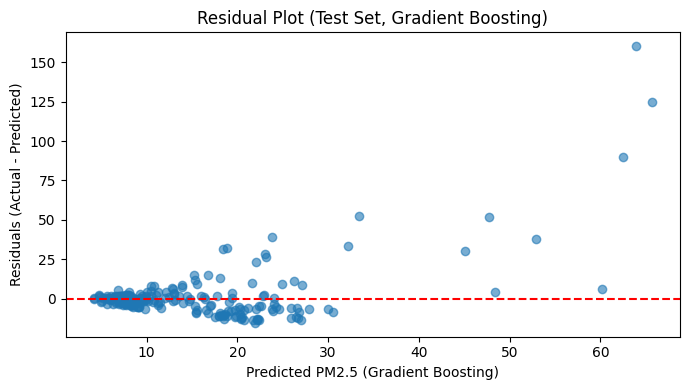

In [ ]:
# 4. Fehleranalyse: Residuenplot
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Gradient Boosting)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Gradient Boosting)")
plt.tight_layout()
plt.show()

### Gradient Boosting mit GridSearch

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Grid für wichtige Hyperparameter
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [10, 20, 50]
}

gb = HistGradientBoostingRegressor(random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_gb = GridSearchCV(gb, param_grid, cv=cv, scoring='r2', n_jobs=-1, verbose=2)
gs_gb.fit(X_train, y_train)

print("\nBeste Parameter (Gradient Boosting):", gs_gb.best_params_)
print("Bestes CV R2: %.3f" % gs_gb.best_score_)

# Bestes Modell auswerten
best_gb = gs_gb.best_estimator_
y_train_pred = best_gb.predict(X_train)
y_test_pred = best_gb.predict(X_test)

print("\nGradient Boosting (Bestes Modell) - Training-Set:")
print("R2:  %.3f" % r2_score(y_train, y_train_pred))
print("MAE: %.2f" % mean_absolute_error(y_train, y_train_pred))
print("MSE: %.2f" % mean_squared_error(y_train, y_train_pred))

print("\nGradient Boosting (Bestes Modell) - Test-Set:")
print("R2:  %.3f" % r2_score(y_test, y_test_pred))
print("MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Beste Parameter (Gradient Boosting): {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 300, 'min_samples_leaf': 10}
Bestes CV R2: 0.831

Gradient Boosting (Bestes Modell) - Training-Set:
R2:  0.995
MAE: 0.54
MSE: 0.57

Gradient Boosting (Bestes Modell) - Test-Set:
R2:  0.583
MAE: 7.21
MSE: 259.73


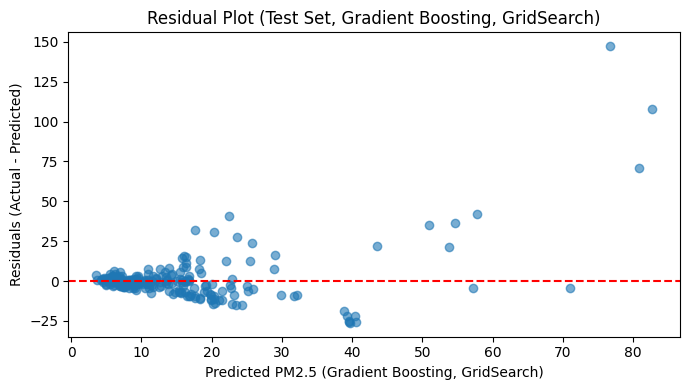

In [ ]:
# Fehleranalyse: Residuenplot
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Gradient Boosting, GridSearch)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Gradient Boosting, GridSearch)")
plt.tight_layout()
plt.show()

### Gradient Boosting Feature Importance

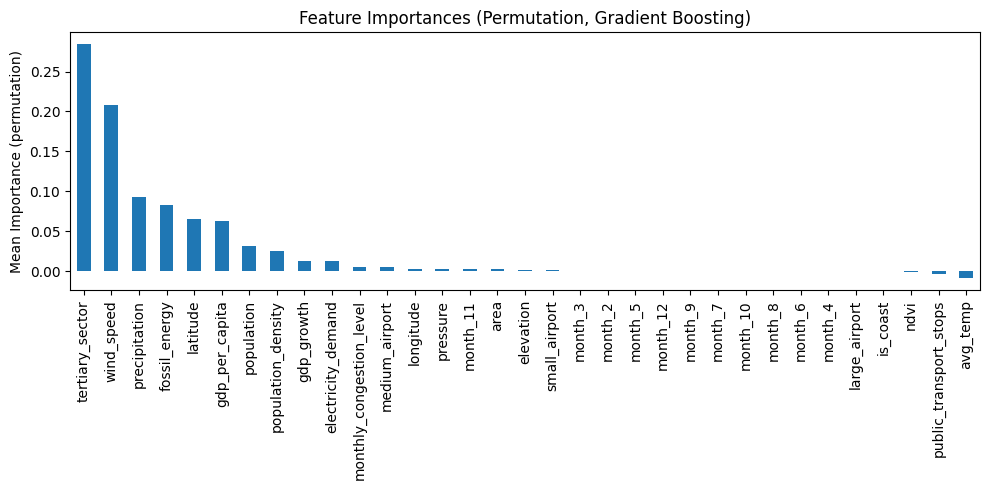

Top 10 wichtigste Features (Permutation Importance, GB):
tertiary_sector       0.284370
wind_speed            0.207999
precipitation         0.092698
fossil_energy         0.082488
latitude              0.065653
gdp_per_capita        0.062284
population            0.031993
population_density    0.025679
gdp_growth            0.013279
electricity_demand    0.012995
dtype: float64


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Permutation Importance auf dem Testset berechnen
result = permutation_importance(best_gb, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# DataFrame für bessere Übersicht
feat_imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.ylabel('Mean Importance (permutation)')
plt.title('Feature Importances (Permutation, Gradient Boosting)')
plt.tight_layout()
plt.show()

# Top 10 ausgeben
print("Top 10 wichtigste Features (Permutation Importance, GB):")
print(feat_imp.head(10))


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# 1. Permutation Importance auf Testdaten berechnen
result = permutation_importance(best_gb, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
feat_imp = pd.Series(result.importances_mean, index=X_test.columns)

# 2. Wichtige Features bestimmen (Threshold 0.01)
important_features = feat_imp[feat_imp > 0.01].index.tolist()
print("Verwendete Features:", important_features)

# 3. Trainings- und Testdaten reduzieren
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

# 4. Kompaktes Modell mit gleichen Hyperparametern trainieren
gb_reduced = HistGradientBoostingRegressor(**best_gb.get_params())
gb_reduced.fit(X_train_reduced, y_train)

# 5. Auswertung
y_train_pred = gb_reduced.predict(X_train_reduced)
y_test_pred = gb_reduced.predict(X_test_reduced)

print("\nKompaktes GB-Modell (nur wichtige Features):")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))
print("Test MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("Test MSE: %.2f" % mean_squared_error(y_test, y_test_pred))


Verwendete Features: ['latitude', 'precipitation', 'wind_speed', 'electricity_demand', 'fossil_energy', 'population', 'population_density', 'gdp_per_capita', 'gdp_growth', 'tertiary_sector']

Kompaktes GB-Modell (nur wichtige Features):
Train R2: 0.985
Test  R2: 0.579
Test MAE: 7.16
Test MSE: 262.32


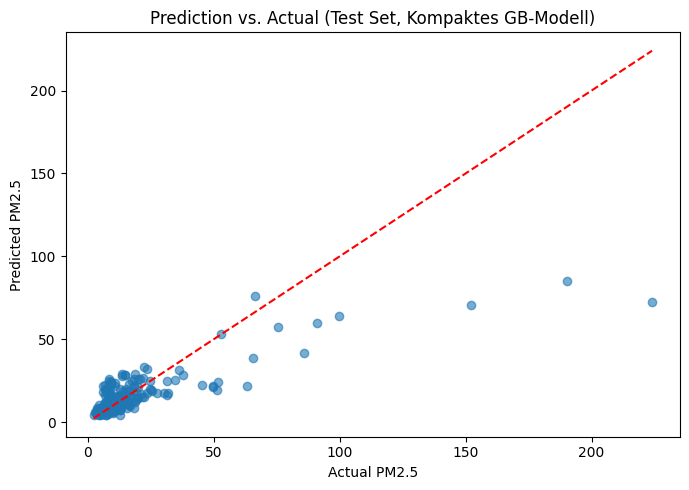

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Prediction vs. Actual (Test Set, Kompaktes GB-Modell)")
plt.tight_layout()
plt.show()


* Im Bereich niedriger bis mittlerer PM2.5-Werte liegen die Vorhersagen sehr nahe an der Idealgeraden.
* Extremwerte werden weiterhin systematisch unterschätzt; das Modell gibt selten sehr hohe PM2.5-Werte aus.
* Insgesamt zeigt das Modell eine gute Vorhersage im typischen Wertebereich, bleibt aber bei Ausreißern konservativ.

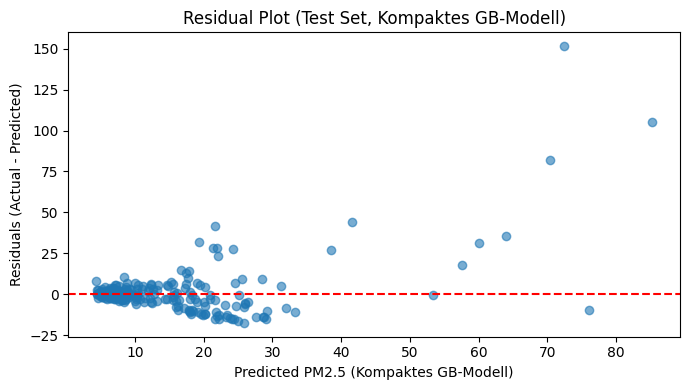

In [ ]:
residuals = y_test - y_test_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (Kompaktes GB-Modell)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, Kompaktes GB-Modell)")
plt.tight_layout()
plt.show()


* Fehler im Hauptbereich klein und symmetrisch um Null.
* Einzelne sehr große Residuen bei hohen Vorhersagen: Das Modell unterschätzt die höchsten PM2.5-Werte deutlich.
* Streuung der Fehler wächst mit steigender Vorhersage (Trichterform) – typisch bei rechtsschiefen Zielverteilungen mit Ausreißern.

## Neural network

### Spalten auswählen und Daten splitten

In [ ]:
# Liste aller Städte
cities = df['city'].unique()
n_cities = len(cities)

# Städte zufällig aufteilen (80% train, 20% test, reproduzierbar)
np.random.seed(42)
n_train = int(n_cities * 0.8)
train_cities = np.random.choice(cities, size=n_train, replace=False)
test_cities = np.setdiff1d(cities, train_cities)

In [ ]:
# DataFrames nach Städte-Split aufteilen
train_mask = df['city'].isin(train_cities)
test_mask = df['city'].isin(test_cities)

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()


In [ ]:
# Spalten entfernen, Zielvariable festlegen
drop_cols = ['year',  'city', 'country_code', 'country']
X_train = train_df.drop(columns=drop_cols + ['pm25'])
y_train = train_df['pm25']

X_test = test_df.drop(columns=drop_cols + ['pm25'])
y_test = test_df['pm25']


In [ ]:
# Monatsdummies erzeugen
X_train = pd.get_dummies(X_train, columns=['month'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['month'], drop_first=True, dtype=int)

# Fehlende Spalten angleichen (falls nötig)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### Neuronales Netz trainieren

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Pipeline mit Skalierung und MLP-Regressor
mlp_pipe = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
)

# 2. Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp_pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
print("MLPRegressor CV R2:", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

# 3. Training auf gesamtem Trainingsset & Auswertung
mlp_pipe.fit(X_train, y_train)
y_train_pred = mlp_pipe.predict(X_train)
y_test_pred = mlp_pipe.predict(X_test)

print("\nMLPRegressor - Training-Set:")
print("R2:  %.3f" % r2_score(y_train, y_train_pred))
print("MAE: %.2f" % mean_absolute_error(y_train, y_train_pred))
print("MSE: %.2f" % mean_squared_error(y_train, y_train_pred))

print("\nMLPRegressor - Test-Set:")
print("R2:  %.3f" % r2_score(y_test, y_test_pred))
print("MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

MLPRegressor CV R2: [0.72149346 0.62306918 0.75801911 0.66038495 0.80784914]
CV R2 Mittelwert: 0.714 ± 0.066

MLPRegressor - Training-Set:
R2:  1.000
MAE: 0.10
MSE: 0.03

MLPRegressor - Test-Set:
R2:  0.611
MAE: 7.72
MSE: 242.31


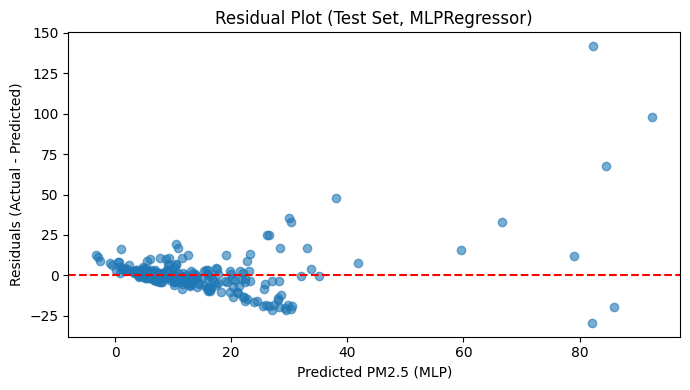

In [ ]:
# 4. Fehleranalyse: Residuenplot
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (MLP)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, MLPRegressor)")
plt.tight_layout()
plt.show()

### Neuronales Netz mit GridSearch

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Beste Parameter (MLP): {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate_init': 0.01}
Bestes CV R2: 0.774

MLP (Bestes Modell) - Training-Set:
R2:  0.993
MAE: 0.66
MSE: 0.76

MLP (Bestes Modell) - Test-Set:
R2:  0.592
MAE: 7.71
MSE: 253.72


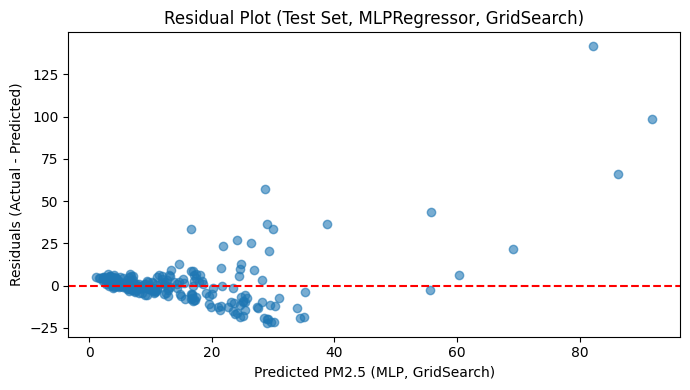

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Pipeline für Skalierung und MLP
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=2000, random_state=42))
])

# 2. Grid für wichtige Hyperparameter
param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50,50)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_mlp = GridSearchCV(pipe, param_grid, cv=cv, scoring='r2', n_jobs=-1, verbose=2)
gs_mlp.fit(X_train, y_train)

print("\nBeste Parameter (MLP):", gs_mlp.best_params_)
print("Bestes CV R2: %.3f" % gs_mlp.best_score_)

# 3. Bestes Modell auswerten
best_mlp = gs_mlp.best_estimator_
y_train_pred = best_mlp.predict(X_train)
y_test_pred = best_mlp.predict(X_test)

print("\nMLP (Bestes Modell) - Training-Set:")
print("R2:  %.3f" % r2_score(y_train, y_train_pred))
print("MAE: %.2f" % mean_absolute_error(y_train, y_train_pred))
print("MSE: %.2f" % mean_squared_error(y_train, y_train_pred))

print("\nMLP (Bestes Modell) - Test-Set:")
print("R2:  %.3f" % r2_score(y_test, y_test_pred))
print("MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

# 4. Fehleranalyse: Residuenplot
residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (MLP, GridSearch)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, MLPRegressor, GridSearch)")
plt.tight_layout()
plt.show()


### Neural Network Feature Importance

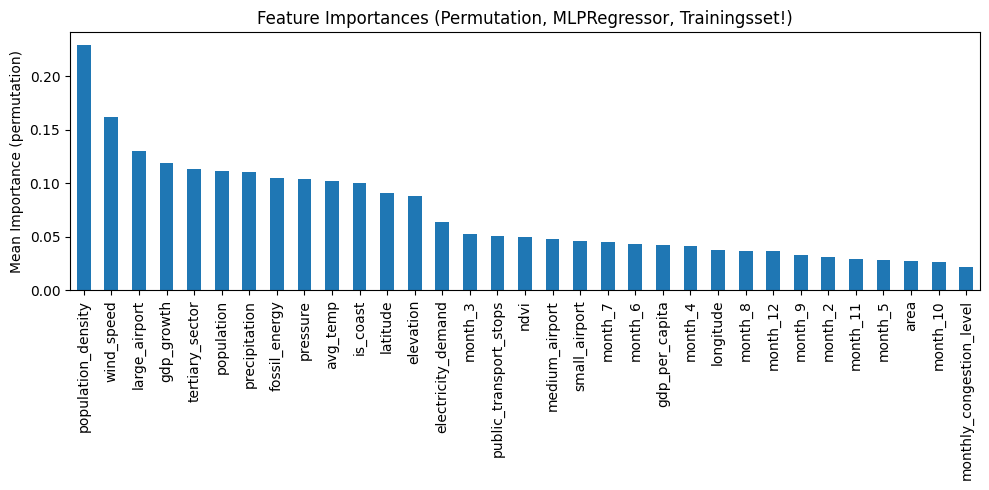

Top 10 wichtigste Features (Permutation Importance, MLP, Trainingsset):
population_density    0.229675
wind_speed            0.162022
large_airport         0.130026
gdp_growth            0.119235
tertiary_sector       0.113218
population            0.111321
precipitation         0.110337
fossil_energy         0.104588
pressure              0.104311
avg_temp              0.102363
dtype: float64


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Permutation Importance auf dem Trainingsset
result = permutation_importance(best_mlp, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
feat_imp = pd.Series(result.importances_mean, index=X_train.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.ylabel('Mean Importance (permutation)')
plt.title('Feature Importances (Permutation, MLPRegressor, Trainingsset!)')
plt.tight_layout()
plt.show()

# Top 10 ausgeben
print("Top 10 wichtigste Features (Permutation Importance, MLP, Trainingsset):")
print(feat_imp.head(10))

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold

# 1. Permutation Importance auf Trainingsset (und Modell auf Trainingsset!) berechnen
mlp_for_imp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(**best_mlp.named_steps['mlp'].get_params()))
])
mlp_for_imp.fit(X_train, y_train)

result = permutation_importance(mlp_for_imp, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
feat_imp = pd.Series(result.importances_mean, index=X_train.columns)
important_features = feat_imp[feat_imp > 0.01].index.tolist()
print("Verwendete Features:", important_features)

# 2. Datensets reduzieren
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

# 3. Kompaktes Modell (erneut auf Trainingsset fitten)
mlp_compact = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(**best_mlp.named_steps['mlp'].get_params()))
])

# Cross-Validation nur auf Trainingsset
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp_compact, X_train_reduced, y_train, cv=cv, scoring='r2', n_jobs=-1)
print("MLP Compact CV R2:", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

mlp_compact.fit(X_train_reduced, y_train)

# 4. Auswertung (wie gehabt)
y_train_pred = mlp_compact.predict(X_train_reduced)
y_test_pred = mlp_compact.predict(X_test_reduced)

print("\nKompaktes MLP-Modell (nur wichtige Features, auf Trainingsset bestimmt):")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))
print("Test MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("Test MSE: %.2f" % mean_squared_error(y_test, y_test_pred))


Verwendete Features: ['latitude', 'longitude', 'elevation', 'is_coast', 'avg_temp', 'precipitation', 'wind_speed', 'pressure', 'ndvi', 'electricity_demand', 'fossil_energy', 'population', 'area', 'population_density', 'large_airport', 'medium_airport', 'small_airport', 'public_transport_stops', 'monthly_congestion_level', 'gdp_per_capita', 'gdp_growth', 'tertiary_sector', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']
MLP Compact CV R2: [0.78034796 0.75351966 0.76318138 0.7201221  0.85391184]
CV R2 Mittelwert: 0.774 ± 0.044

Kompaktes MLP-Modell (nur wichtige Features, auf Trainingsset bestimmt):
Train R2: 0.993
Test  R2: 0.592
Test MAE: 7.71
Test MSE: 253.72


Überflüssig --> es werden alle Features behalten

### Neuronales Netz mit Log und Sqrt Transformation

In [ ]:
# Log Transformation
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import pandas as pd

# Zielvariable log-transformieren
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 1. Permutation Importance im log-Raum (auf Trainingsset!)
mlp_for_imp_log = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(**best_mlp.named_steps['mlp'].get_params()))
])
mlp_for_imp_log.fit(X_train, y_train_log)

result_log = permutation_importance(mlp_for_imp_log, X_train, y_train_log, n_repeats=10, random_state=42, n_jobs=-1)
feat_imp_log = pd.Series(result_log.importances_mean, index=X_train.columns)
important_features_log = feat_imp_log[feat_imp_log > 0.01].index.tolist()
print("Verwendete Features (im log-Raum):", important_features_log)

# 2. Datensets reduzieren
X_train_reduced_log = X_train[important_features_log]
X_test_reduced_log = X_test[important_features_log]

# 3. Kompaktes Modell (erneut auf Trainingsset fitten, im log-Raum)
mlp_compact_log = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(**best_mlp.named_steps['mlp'].get_params()))
])

# Cross-Validation auf log-transformiertem Target
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp_compact_log, X_train_reduced_log, y_train_log, cv=cv, scoring='r2', n_jobs=-1)
print("MLP Compact CV R2 (log-Target):", cv_scores)
print("CV R2 Mittelwert: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

mlp_compact_log.fit(X_train_reduced_log, y_train_log)

# 4. Vorhersagen und Rücktransformation
y_train_pred_log = mlp_compact_log.predict(X_train_reduced_log)
y_test_pred_log = mlp_compact_log.predict(X_test_reduced_log)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

print("\nKompaktes MLP-Modell (Log-Transformation, wichtige Features):")
print("Train R2: %.3f" % r2_score(y_train, y_train_pred))
print("Test  R2: %.3f" % r2_score(y_test, y_test_pred))
print("Test MAE: %.2f" % mean_absolute_error(y_test, y_test_pred))
print("Test MSE: %.2f" % mean_squared_error(y_test, y_test_pred))

Verwendete Features (im log-Raum): ['latitude', 'longitude', 'elevation', 'is_coast', 'avg_temp', 'precipitation', 'wind_speed', 'pressure', 'ndvi', 'electricity_demand', 'fossil_energy', 'population', 'area', 'population_density', 'large_airport', 'medium_airport', 'small_airport', 'public_transport_stops', 'monthly_congestion_level', 'gdp_per_capita', 'gdp_growth', 'tertiary_sector', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']
MLP Compact CV R2 (log-Target): [0.43606719 0.6894034  0.73110437 0.73285087 0.7346329 ]
CV R2 Mittelwert: 0.665 ± 0.116

Kompaktes MLP-Modell (Log-Transformation, wichtige Features):
Train R2: 0.991
Test  R2: 0.404
Test MAE: 8.65
Test MSE: 371.02


Die Log-Transformation macht aus großen Unterschieden kleine.   
Beispiel:   
	•	PM2.5 = 5 → log1p ≈ 1.79    
	•	PM2.5 = 100 → log1p ≈ 4.61   
	•	Dadurch werden Extremwerte und Ausreißer im Modell „näher zusammengerückt“ sodass das Modell Unterschiede zwischen normalen und hohen PM2.5 kaum noch lernt.   
	•	Nach der Rücktransformation (np.expm1) wirken kleine Fehler im log-Raum als große Fehler im Originalraum.

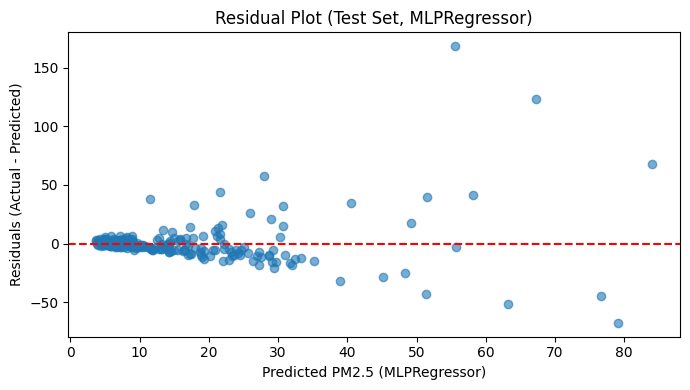

In [ ]:
# Residuenplot
residuals = y_test - y_test_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5 (MLPRegressor)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set, MLPRegressor)")
plt.tight_layout()
plt.show()

# Comparison of the models

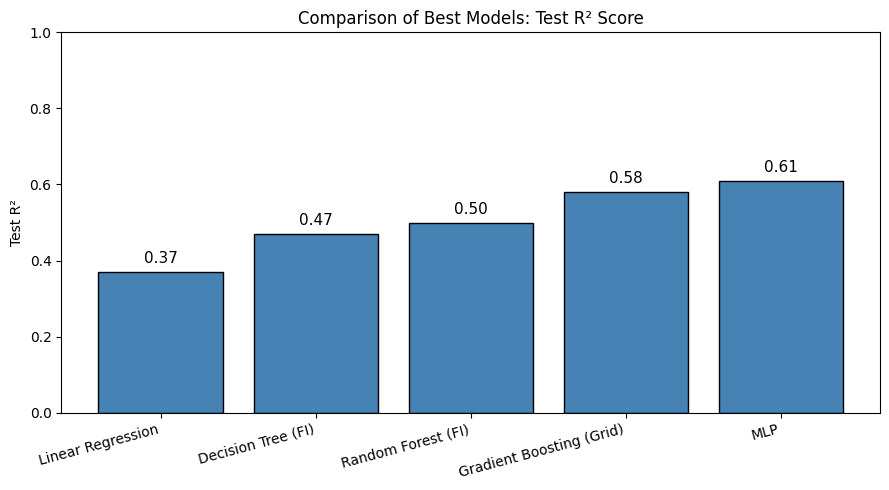

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Namen der Modelle (nur Gewinner/Best-of)
models = [
    "Linear Regression",
    "Decision Tree (FI)",
    "Random Forest (FI)",
    "Gradient Boosting (Grid)",
    "MLP"
]

# Die zugehörigen Test R²-Werte (aus deiner Tabelle)
test_r2 = [0.37, 0.47, 0.50, 0.58, 0.61]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, test_r2, color='steelblue', edgecolor='k')
plt.ylabel("Test R²")
plt.title("Comparison of Best Models: Test R² Score")
plt.ylim(0, 1)

# Werte auf die Balken schreiben (optional)
for bar, value in zip(bars, test_r2):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.2f}",
        ha='center', va='bottom', fontsize=11
    )

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()
